# Logistic Regression

**Objective:** In this example, the [statsmodels](https://www.statsmodels.org/stable/index.html) library is used to perform a logistic regression using data from the file "TaxiTripSmall.xlsx". The goal is to predict whether the payment was made using a credit card based on the values of other variables such as 'TipAmount', 'PassengerCount', or 'SurchargeAmount'.

**Author:** Dr. Juan Manuel Ahuactzin Larios

In [23]:
# Data libraries
import pandas as pd
import numpy as np

# Graph
import matplotlib.pyplot as plt
from matplotlib import style

# Processing and models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import ConfusionMatrixDisplay

#Statistics
import statsmodels.api as sm

### matplotlib and warnings configuration

In [24]:
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# warning configuration
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Data Loading 

In [25]:
data = pd.read_excel("../data/TaxiTripSmall.xlsx", index_col = 0)
data

,MedallionID,HackneyLicenseID,PickupTimeID,DropoffTimeID,PickupGeographyID,DropoffGeographyID,PickupLatitude,PickupLongitude,PickupLatLong,DropoffLatitude,...,PassengerCount,TripDurationSeconds,TripDistanceMiles,PaymentType,FareAmount,SurchargeAmount,TaxAmount,TipAmount,TollsAmount,TotalAmount
DateID,,,,,,,,,,,,,,,,,,,,,
20131228,77,6072,3110,3746,153121,260619,40.7420,-73.9809,"40.742,-73.9809",40.7448,...,1,635,1.90,CRD,9.5,0.5,0.5,1.0,0.0,11.5
20131221,6070,9924,79788,80861,57596,201464,40.7628,-73.9680,"40.7628,-73.968",40.7583,...,2,1072,1.30,CRD,11.5,0.5,0.5,2.5,0.0,15.0
20131231,3603,31156,43440,43860,110568,300756,40.7729,-73.9500,"40.7729,-73.95",40.7802,...,1,420,0.89,CSH,6.5,0.0,0.5,0.0,0.0,7.0
20131231,4760,8499,24360,24660,254721,202397,40.7758,-73.9499,"40.7758,-73.9499",40.7806,...,1,300,0.78,CSH,5.0,0.0,0.5,0.0,0.0,5.5
20131222,1928,32734,10428,11005,33178,52302,40.7278,-73.9851,"40.7278,-73.9851",40.7615,...,1,576,2.70,CRD,10.5,0.5,0.5,2.3,0.0,13.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20131220,8354,5056,29400,29760,23976,219478,40.8114,-73.9616,"40.8114,-73.9616",40.7975,...,5,360,1.13,CSH,6.5,0.0,0.5,0.0,0.0,7.0
20131220,1225,24869,77520,78060,47387,256392,40.7172,-73.9905,"40.7172,-73.9905",40.7291,...,1,540,1.33,CSH,8.0,0.5,0.5,0.0,0.0,9.0
20131219,10072,15034,13014,13319,197791,239432,40.7789,-73.9623,"40.7789,-73.9623",40.7492,...,2,304,2.40,CRD,8.5,0.5,0.5,1.9,0.0,11.4


### Convert the 'PaymentType' variable from a categorical to a numerical value

In [26]:
cleanup_PaymentType = {"PaymentType":     {"CRD": 1, "CSH": 0, "DIS": 0, "NOC": 0, "UNK": 0} }
data = data.replace(cleanup_PaymentType)
display(data)

,MedallionID,HackneyLicenseID,PickupTimeID,DropoffTimeID,PickupGeographyID,DropoffGeographyID,PickupLatitude,PickupLongitude,PickupLatLong,DropoffLatitude,...,PassengerCount,TripDurationSeconds,TripDistanceMiles,PaymentType,FareAmount,SurchargeAmount,TaxAmount,TipAmount,TollsAmount,TotalAmount
DateID,,,,,,,,,,,,,,,,,,,,,
20131228,77,6072,3110,3746,153121,260619,40.7420,-73.9809,"40.742,-73.9809",40.7448,...,1,635,1.90,1,9.5,0.5,0.5,1.0,0.0,11.5
20131221,6070,9924,79788,80861,57596,201464,40.7628,-73.9680,"40.7628,-73.968",40.7583,...,2,1072,1.30,1,11.5,0.5,0.5,2.5,0.0,15.0
20131231,3603,31156,43440,43860,110568,300756,40.7729,-73.9500,"40.7729,-73.95",40.7802,...,1,420,0.89,0,6.5,0.0,0.5,0.0,0.0,7.0
20131231,4760,8499,24360,24660,254721,202397,40.7758,-73.9499,"40.7758,-73.9499",40.7806,...,1,300,0.78,0,5.0,0.0,0.5,0.0,0.0,5.5
20131222,1928,32734,10428,11005,33178,52302,40.7278,-73.9851,"40.7278,-73.9851",40.7615,...,1,576,2.70,1,10.5,0.5,0.5,2.3,0.0,13.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20131220,8354,5056,29400,29760,23976,219478,40.8114,-73.9616,"40.8114,-73.9616",40.7975,...,5,360,1.13,0,6.5,0.0,0.5,0.0,0.0,7.0
20131220,1225,24869,77520,78060,47387,256392,40.7172,-73.9905,"40.7172,-73.9905",40.7291,...,1,540,1.33,0,8.0,0.5,0.5,0.0,0.0,9.0
20131219,10072,15034,13014,13319,197791,239432,40.7789,-73.9623,"40.7789,-73.9623",40.7492,...,2,304,2.40,1,8.5,0.5,0.5,1.9,0.0,11.4


In [27]:
prop = data.PaymentType.value_counts().sort_index()
prop

PaymentType
0    2583
1    2417
Name: count, dtype: int64

In [28]:
proba_CRD = prop[1] / (prop[0] + prop[1])
print("Probability of CRD: ", proba_CRD)

Probability of CRD:  0.4834


### Select predictor variables and target variable

## 

In [29]:
# X = data[['TipAmount']]
# X = data[['SurchargeAmount']]
X = data[['PassengerCount']]
# X = data[['TipAmount', 'PassengerCount']]
# X = data[['PassengerCount', 'SurchargeAmount']]
# X = data[['TipAmount', 'PassengerCount', 'SurchargeAmount']]


y = data['PaymentType']
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values,
                                        train_size   = 0.8,
                                        random_state = 1966,
                                        shuffle      = True
                                    )

### Logistic Regression Model Training

In [30]:
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.Logit(endog=y_train, exog=X_train,)
modelo = modelo.fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.679271
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3998
Method:                           MLE   Df Model:                            1
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01965
Time:                        15:13:26   Log-Likelihood:                -2717.1
converged:                       True   LL-Null:                       -2771.5
Covariance Type:            nonrobust   LLR p-value:                 1.710e-25
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3891      0.053      7.345      0.000       0.285       0.493
PassengerCount   

In [31]:
# Retrieve the Model Coefficients
coeficientes = modelo.params
w0 = coeficientes[0]
w1 = coeficientes[1]
print(f"Intercept: {w0}")
print(f"Slope: {w1}")

Intercept: 0.3891096042915042
Slope: -0.2487041884351834


Let us compute $\frac{e^{W_0}}{1+e^{W_0}}$, which corresponds to $P(y=1 \mid X=x)$ when all other predictors are set to zero. For example, if we select:

```python
X = data[['TipAmount']]
```

in the code above, then $\frac{e^{W_0}}{1+e^{W_0}}$ represents the probability of paying with a credit card when TipAmount = 0.0. That is, we obtain:

$P(y = \text{CRD} \mid \text{TipAmount} = 0.0)$

In [32]:
probabilidad = np.exp(w0) / (1 + np.exp(w0))
print(probabilidad)

0.5960683362936928


### Compute Confidence Intervals for the Coefficients

In [33]:
intervalos_ci = modelo.conf_int(alpha=0.05)
intervalos_ci = pd.DataFrame(intervalos_ci)
intervalos_ci.columns = ['2.5%', '97.5%']
intervalos_ci

,2.5%,97.5%
const,0.285280,0.492939
PassengerCount,-0.297322,-0.200087


### Generate Predictions

In [34]:
test_predictions = modelo.predict(exog = X_train)
test_predictions[:4]

DateID
20131228    0.472952
20131230    0.535044
20131229    0.535044
20131231    0.535044
dtype: float64

### Classify Based on Predicted Probabilities

In [35]:
classification = np.where(test_predictions<0.5, 0, 1)
classification

array([0, 1, 1, ..., 0, 1, 1])

In [36]:
data.TipAmount

DateID
20131228    1.0
20131221    2.5
20131231    0.0
20131231    0.0
20131222    2.3
           ... 
20131220    0.0
20131220    0.0
20131219    1.9
20131227    0.0
20131229    0.0
Name: TipAmount, Length: 5000, dtype: float64

### Create a Range for Plotting the Results

In [37]:
if len(X.columns) == 1:
   grid_X = np.linspace(
               start = min(X.iloc[:, 0]),
               stop  = max(X.iloc[:, 0]),
               num   = 200
            ).reshape(-1,1)

   grid_X = sm.add_constant(grid_X, prepend=True)
   test_predictions = modelo.predict(exog = grid_X)

### Plot the Results (Only for regressions with one predictor)

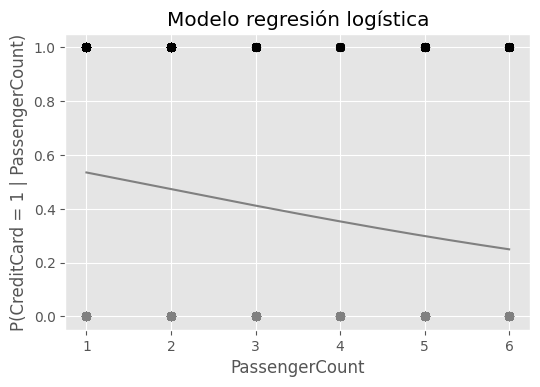

In [38]:
if len(X.columns) == 1:
    fig, ax = plt.subplots(figsize=(6, 3.84))

    ax.scatter(
        X_train.iloc[(y_train == 0).flatten(), 1],
        y_train[(y_train == 0).flatten()].flatten(),
        color = "gray"
    )
    ax.scatter(
        X_train.iloc[(y_train == 1).flatten(), 1],
        y_train[(y_train == 1).flatten()].flatten(),
        color = "black"
    )

    ax.plot(grid_X[:, 1], test_predictions, color = "gray")
    ax.set_title("Modelo regresión logística")
    x_label = X.columns[0]
    ax.set_ylabel(f"P(CreditCard = 1 | {x_label})")
    ax.set_xlabel(x_label);

### Predictions on the Test Set

In [39]:
X_test = sm.add_constant(X_test, prepend=True)
test_predictions = modelo.predict(exog = X_test)
classification = np.where(test_predictions<0.5, 0, 1)
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = classification,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")

rmse = root_mean_squared_error(
    y_true    = y_test,
    y_pred    = classification
)

print("")
print(f"Root Mean Square Error : {rmse}")


El accuracy de test es: 54.800000000000004%

Root Mean Square Error : 0.6723094525588644


### Confusion matrix

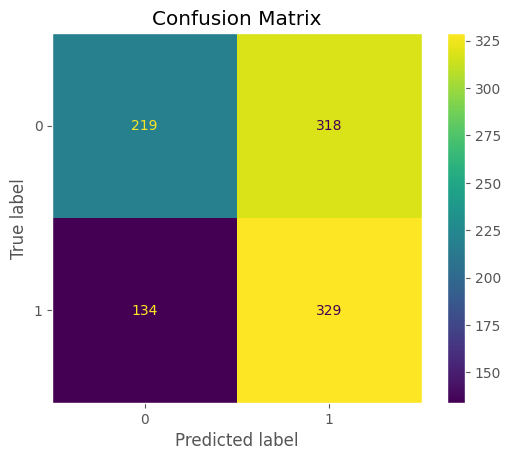

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, classification)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

### Normalized confusion Matrix

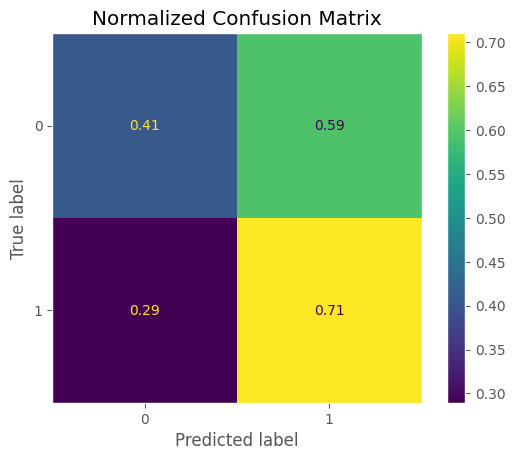

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    classification,
    normalize="true"
)
plt.grid(False)
plt.title("Normalized Confusion Matrix")
plt.show()

In [42]:
num_thresholds = 2000

acceptance_threshold = np.linspace(
            start = 1.0/num_thresholds,
            stop  = 1.0,
            num   = num_thresholds
         )

accurracy_list =[]
best_threshold = 0.0
best_accurracy = 0.0

for threshold in acceptance_threshold:
    classification = np.where(test_predictions<threshold, 0, 1)
    accurracy = accuracy_score(
        y_true = y_test,
        y_pred    = classification,
        normalize = True)
    accurracy_list.append(accurracy)
    if accurracy > best_accurracy:
        best_accurracy = accurracy
        best_threshold = threshold

print("Best threshold = ", best_threshold, "with an accurracy of", best_accurracy*100,"%")   

Best threshold =  0.47300000000000003 with an accurracy of 54.800000000000004 %


Text(0.5, 0, 'Threshold')

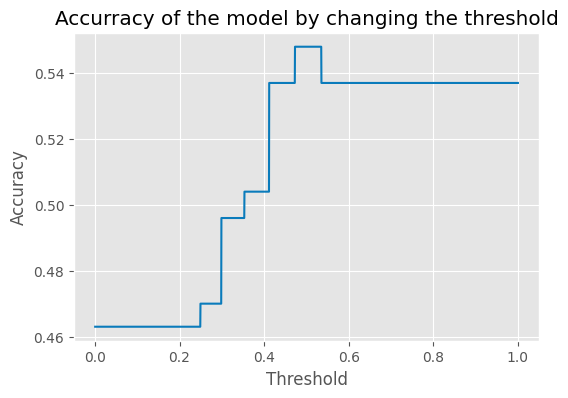

In [43]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(acceptance_threshold, accurracy_list, color = "#0A7BBB")
ax.set_title("Accurracy of the model by changing the threshold")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Threshold")